✅ Libraries imported successfully!

✅ Data loaded successfully!
Shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------

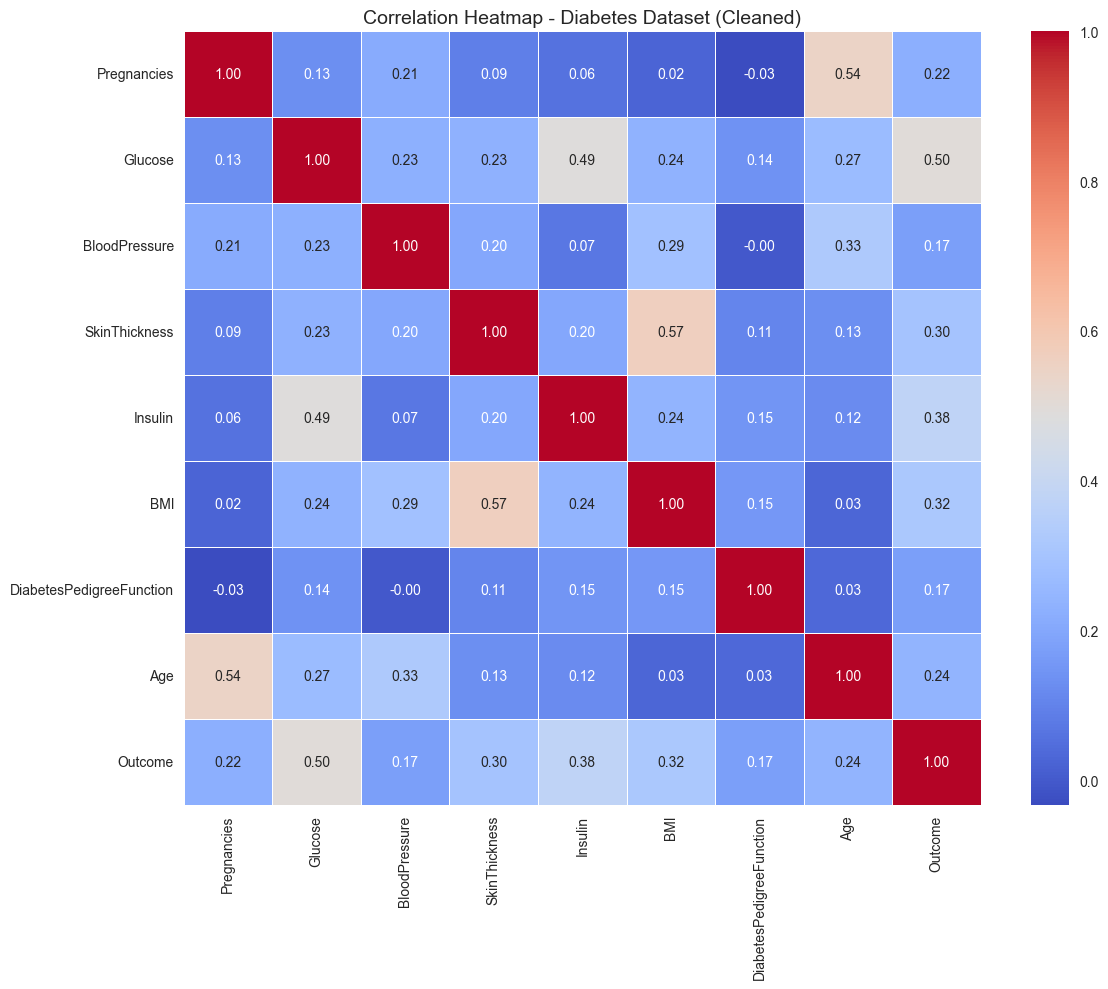


Training samples: 614
Testing samples : 154

MODEL PERFORMANCE

🔹 Logistic Regression  → Accuracy: 0.7078
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154


🔹 Decision Tree        → Accuracy: 0.8117
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       100
           1       0.75      0.70      0.72        54

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154


🔹 Random Forest        → Accuracy: 0.8636
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       100
           1       0.82      0.78      0.80 

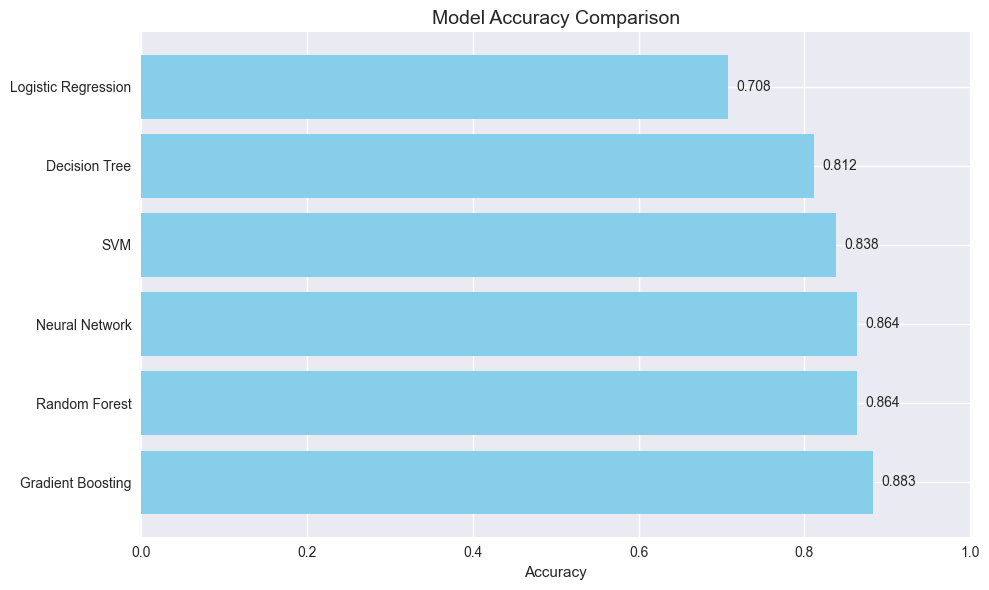


🎉 Script completed successfully!


In [3]:
# =====================================================
# DIABETES PREDICTION MODELS
# Clean Python Script for VS Code / Local Environment
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ Libraries imported successfully!\n")

# =====================================================
# 1. LOAD DATA
# =====================================================
data_path = 'dataset/diabetes.csv'   # ← Change only if path is different

df = pd.read_csv(data_path)

print("✅ Data loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

# =====================================================
# 2. DATA EXPLORATION
# =====================================================
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# =====================================================
# 3. CHECK ZERO VALUES (Missing Data)
# =====================================================
print("\n" + "="*50)
print("ZERO VALUES CHECK")
print("="*50)

cols_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_to_check:
    zeros = (df[col] == 0).sum()
    print(f"{col:15} → {zeros:3d} zeros ({zeros/768*100:.2f}%)")

# =====================================================
# 4. DATA CLEANING
# =====================================================
df_clean = df.copy()

# Replace 0 with NaN
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# Impute with median by Outcome
for col in ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness', 'Insulin']:
    df_clean[col] = df_clean[col].fillna(df_clean.groupby('Outcome')[col].transform('median'))

print("\n✅ Missing values handled successfully!")
print(df_clean.isnull().sum())

# =====================================================
# 5. CORRELATION HEATMAP
# =====================================================
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Diabetes Dataset (Cleaned)', fontsize=14)
plt.tight_layout()
plt.show()

# =====================================================
# 6. PREPARE DATA FOR MODELING
# =====================================================
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

# =====================================================
# 7. TRAIN AND EVALUATE MODELS
# =====================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

results = []

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, round(acc, 4)])
    
    print(f"\n🔹 {name:20} → Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

# =====================================================
# 8. RESULTS SUMMARY
# =====================================================
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("\n" + "="*50)
print("FINAL MODEL COMPARISON")
print("="*50)
print(results_df)

# =====================================================
# 9. VISUALIZATION
# =====================================================
plt.figure(figsize=(10, 6))
bars = plt.barh(results_df['Model'], results_df['Accuracy'], color='skyblue')
plt.title('Model Accuracy Comparison', fontsize=14)
plt.xlabel('Accuracy')
plt.xlim(0, 1)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center')

plt.tight_layout()
plt.show()

print("\n🎉 Script completed successfully!")

✅ Libraries imported!

✅ Data Loaded! Shape: (768, 9)
✅ Data cleaned!


MODEL PERFORMANCE
Logistic Regression  → Accuracy: 0.7078
Decision Tree        → Accuracy: 0.8247
Random Forest        → Accuracy: 0.8636
Gradient Boosting    → Accuracy: 0.8831
SVM                  → Accuracy: 0.8377
Neural Network       → Accuracy: 0.8636


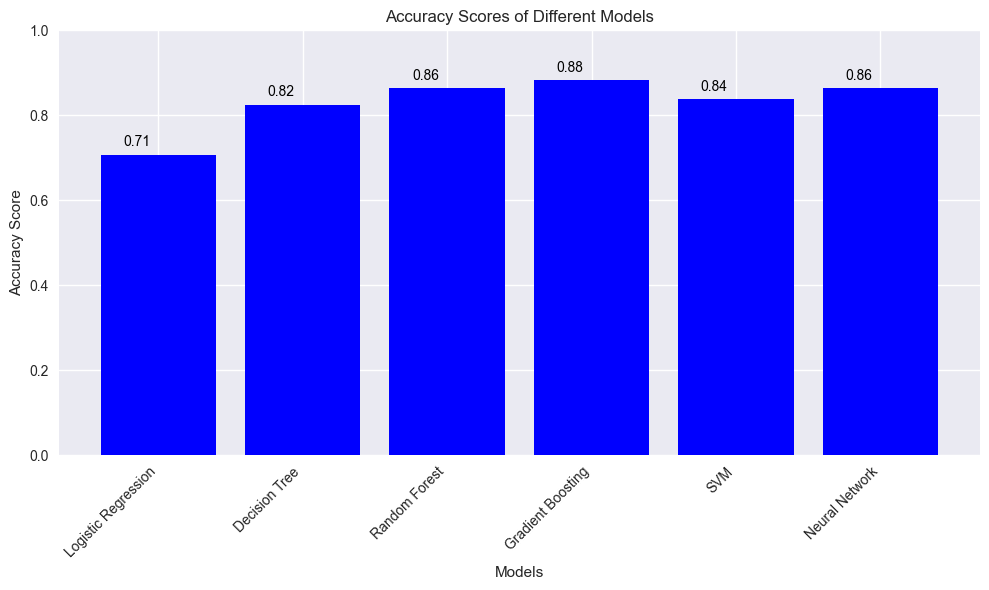


📊 Plotting Decision Tree...


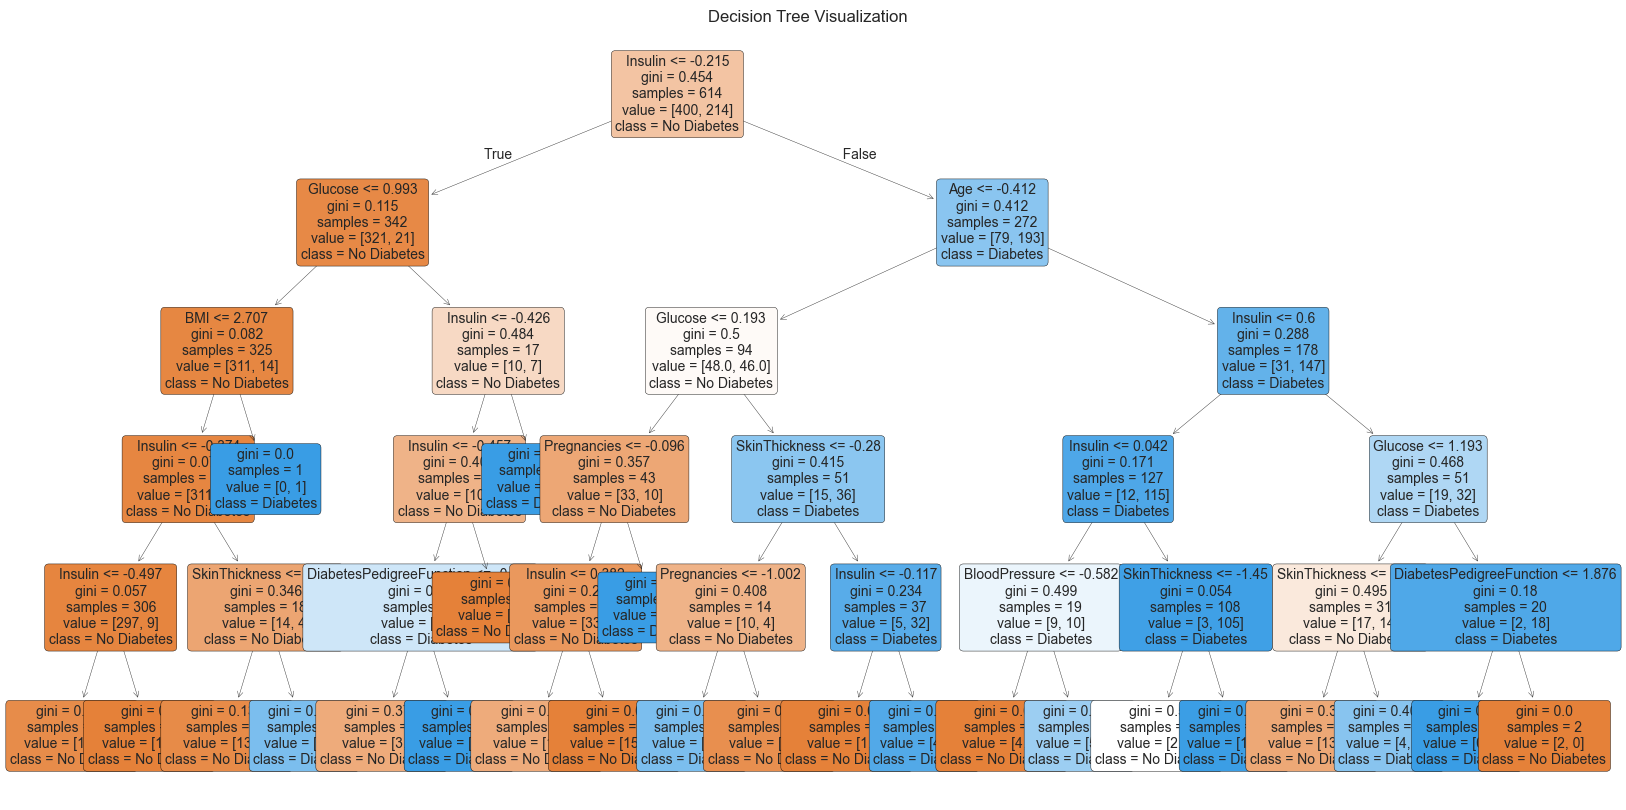

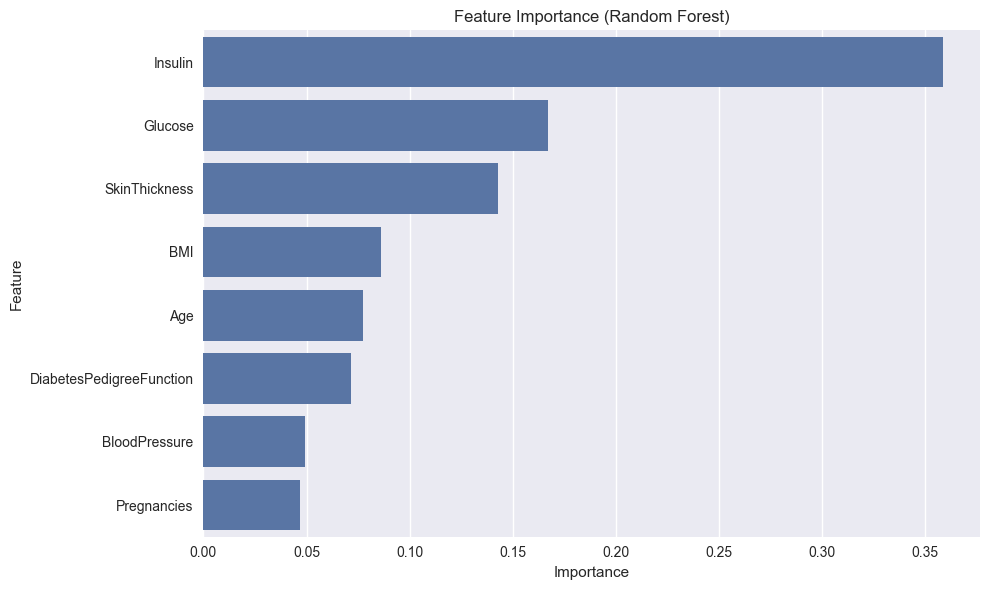


🎉 All visualizations completed!


In [7]:
# =====================================================
# DIABETES PREDICTION MODELS - WITH DECISION TREE VISUALIZATION
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore')

print("✅ Libraries imported!\n")

# =====================================================
# 1. LOAD DATA
# =====================================================
df = pd.read_csv('dataset/diabetes.csv')
print("✅ Data Loaded! Shape:", df.shape)

# =====================================================
# 2. DATA CLEANING
# =====================================================
df_clean = df.copy()

for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df_clean[col] = df_clean[col].replace(0, np.nan)

for col in ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness', 'Insulin']:
    df_clean[col] = df_clean[col].fillna(df_clean.groupby('Outcome')[col].transform('median'))

print("✅ Data cleaned!\n")

# =====================================================
# 3. PREPARE DATA
# =====================================================
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================
# 4. TRAIN MODELS
# =====================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),   # Limited depth for better visualization
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42)
}

model_names = []
accuracy_scores = []

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    
    model_names.append(name)
    accuracy_scores.append(acc)
    
    print(f"{name:20} → Accuracy: {acc:.4f}")

# =====================================================
# 5. VISUALIZATION 1: Accuracy Bar Chart
# =====================================================
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracy_scores, color='blue')
plt.xlabel('Models')
plt.ylabel('Accuracy Score')
plt.title('Accuracy Scores of Different Models')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')

for bar, accuracy in zip(bars, accuracy_scores):
    plt.text(bar.get_x() + bar.get_width()/2 - 0.15, 
             bar.get_height() + 0.02, 
             f'{accuracy:.2f}', ha='center', color='black')

plt.tight_layout()
plt.show()

# =====================================================
# 6. DECISION TREE VISUALIZATION
# =====================================================
print("\n📊 Plotting Decision Tree...")

dt_model = models["Decision Tree"]

plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=X.columns, 
          class_names=['No Diabetes', 'Diabetes'],
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization')
plt.show()

# =====================================================
# 7. FEATURE IMPORTANCE (Random Forest)
# =====================================================
rf_model = models["Random Forest"]
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

print("\n🎉 All visualizations completed!")

✅ Libraries imported!

✅ Data Loaded! Shape: (768, 9)
✅ Zero values handled!


OUTLIER HANDLING
Pregnancies     →   4 outliers capped
Glucose         →   0 outliers capped
BloodPressure   →  14 outliers capped
SkinThickness   →  87 outliers capped
Insulin         →  51 outliers capped
BMI             →   8 outliers capped
DiabetesPedigreeFunction →  29 outliers capped
Age             →   9 outliers capped

Training samples: 614
Testing samples : 154

MODEL PERFORMANCE

🔹 Logistic Regression  → Accuracy: 0.7532


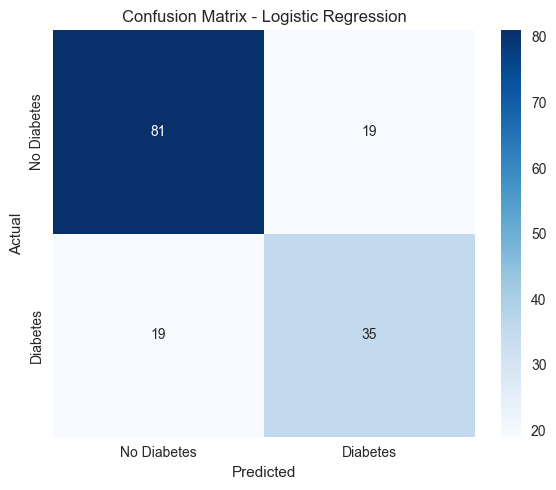


🔹 Decision Tree        → Accuracy: 0.8247


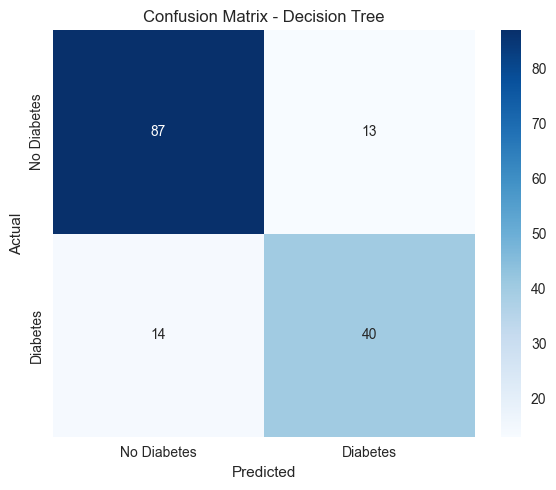


🔹 Random Forest        → Accuracy: 0.8571


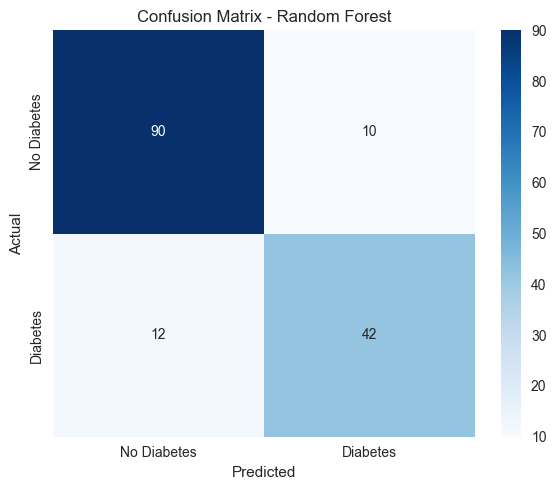


🔹 Gradient Boosting    → Accuracy: 0.8961


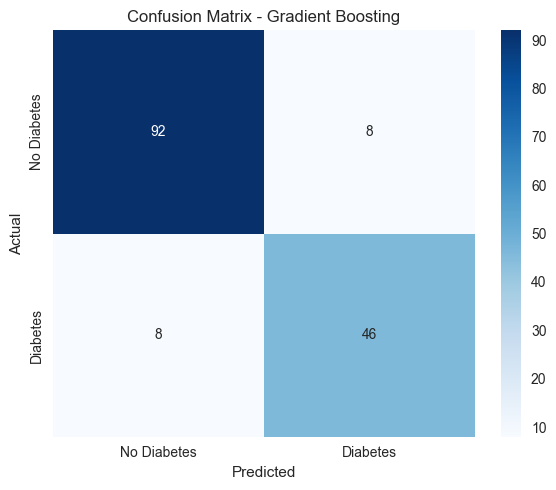


🔹 SVM                  → Accuracy: 0.8442


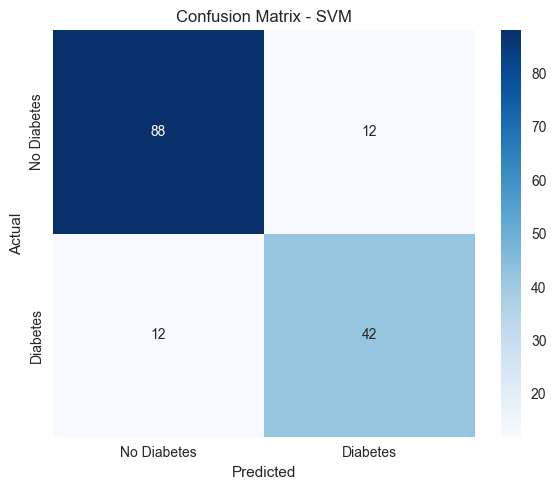


🔹 Neural Network       → Accuracy: 0.8506


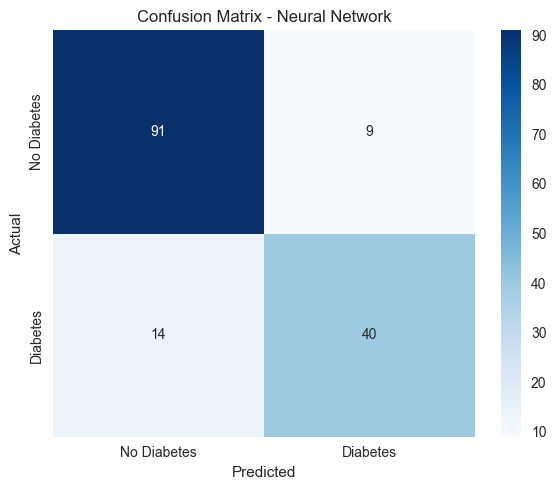

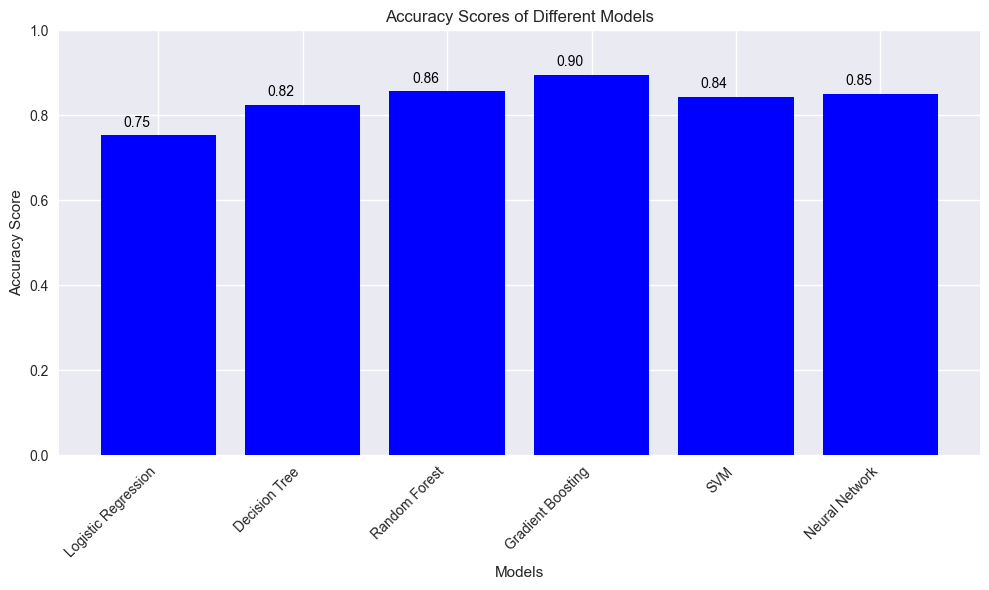


🎉 All done! Outliers handled + All models evaluated.


In [8]:
# =====================================================
# DIABETES PREDICTION MODELS - WITH OUTLIER HANDLING
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore')

print("✅ Libraries imported!\n")

# =====================================================
# 1. LOAD DATA
# =====================================================
df = pd.read_csv('dataset/diabetes.csv')
print("✅ Data Loaded! Shape:", df.shape)

# =====================================================
# 2. DATA CLEANING (Zeros → NaN)
# =====================================================
df_clean = df.copy()

for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# Impute with median by Outcome
for col in ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness', 'Insulin']:
    df_clean[col] = df_clean[col].fillna(df_clean.groupby('Outcome')[col].transform('median'))

print("✅ Zero values handled!\n")

# =====================================================
# 3. OUTLIER HANDLING (IQR Method - Capping)
# =====================================================
def handle_outliers(df, columns):
    df_out = df.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Cap the outliers
        df_out[col] = df_out[col].clip(lower=lower_bound, upper=upper_bound)
        
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        print(f"{col:15} → {outliers:3d} outliers capped")
    return df_out

# Handle outliers on numerical columns
numerical_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

print("\n" + "="*50)
print("OUTLIER HANDLING")
print("="*50)
df_clean = handle_outliers(df_clean, numerical_cols)

# =====================================================
# 4. PREPARE DATA FOR MODELING
# =====================================================
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

# =====================================================
# 5. TRAIN MODELS + CONFUSION MATRICES
# =====================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42)
}

model_names = []
accuracy_scores = []

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    
    model_names.append(name)
    accuracy_scores.append(acc)
    
    print(f"\n🔹 {name:20} → Accuracy: {acc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# =====================================================
# 6. ACCURACY COMPARISON CHART
# =====================================================
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracy_scores, color='blue')
plt.xlabel('Models')
plt.ylabel('Accuracy Score')
plt.title('Accuracy Scores of Different Models')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')

for bar, accuracy in zip(bars, accuracy_scores):
    plt.text(bar.get_x() + bar.get_width()/2 - 0.15, 
             bar.get_height() + 0.02, 
             f'{accuracy:.2f}', ha='center', color='black')

plt.tight_layout()
plt.show()

print("\n🎉 All done! Outliers handled + All models evaluated.")